# Baseline Sentiment Classification Model

This notebook builds a baseline machine learning model as a first step toward 
the project's Aspect-Based Sentiment Analysis goal. Before extracting sentiment 
per aspect (battery, display, build quality, etc.), a simpler overall sentiment 
classification model is built first, to establish a working pipeline and a 
performance baseline.

**Problem definition:** Predict whether a review expresses positive or negative 
sentiment, based on the review text itself.

**Target variable:** Sentiment label, derived from `rating`:
- Ratings 1-3 → Negative
- Ratings 4-5 → Positive

**Why 2-class instead of 3-class (with Neutral):** The dataset is heavily 
skewed toward 5-star ratings (58%, per EDA), so a 3-class split 
would leave very few examples for a Neutral class, making the baseline 
unstable. A 2-class split gives a simpler, more reliable starting point. 
This decision will be revisited with the mentor, and can be changed once 
this baseline is working end-to-end.

**Features:** The review text (`review` column), converted into numeric 
features the model can use.

## Setup

Loading the enriched dataset and importing libraries needed for text 
processing and modeling.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report, confusion_matrix

df = pd.read_csv("../data/processed/processed_data_enriched.csv")
df[["review", "rating"]].head()

,review,rating
0,"Loved it, it's my first MacBook that I earned ...",5
1,Battery lasted longer than my first relationsh...,5
2,Such a great deal.. very happy with the perfor...,5
3,"Awesome build quality and very good display, b...",4
4,When i ordered and came to know about seller r...,5


## Creating the sentiment target

Ratings are mapped into a binary sentiment label: ratings 1-3 become Negative, 
ratings 4-5 become Positive. This becomes the target variable (y) the model 
will learn to predict.

In [8]:
# Map star ratings into a binary sentiment label.
# Ratings 1-3 are treated as Negative, ratings 4-5 as Positive.
df["sentiment"] = df["rating"].apply(lambda r: "Positive" if r >= 4 else "Negative")

# Check class balance, this tells us how imbalanced the target is,
# which affects both how we split the data and how we'll evaluate the model.
df["sentiment"].value_counts(normalize=True)

sentiment
Positive    0.816138
Negative    0.183862
Name: proportion, dtype: float64

## Train/test split

The dataset is split into training data (used to fit the model) and test 
data (held back, used only to evaluate performance on unseen reviews). 
A stratified split is used so that both the training and test sets keep 
the same proportion of Positive and Negative reviews as the full dataset, 
this matters because the sentiment classes are imbalanced.

In [9]:
# X is the input the model learns from (review text).
# y is what we're trying to predict (sentiment label).
X = df["review"]
y = df["sentiment"]

# test_size=0.2 means 20% of data is held back purely for testing.
# stratify=y ensures the class balance (Positive/Negative ratio) is
# preserved in both the training and test sets.
# random_state=42 makes the split reproducible, running this again
# gives the exact same split rather than a new random one each time.
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# Confirm the split sizes and that class balance held up in both sets
print("Training set size:", X_train.shape[0])
print("Test set size:", X_test.shape[0])
print("\nTraining set class balance:")
print(y_train.value_counts(normalize=True))
print("\nTest set class balance:")
print(y_test.value_counts(normalize=True))

Training set size: 13592
Test set size: 3399

Training set class balance:
sentiment
Positive    0.816142
Negative    0.183858
Name: proportion, dtype: float64

Test set class balance:
sentiment
Positive    0.816122
Negative    0.183878
Name: proportion, dtype: float64


## Baseline model (majority class)

Before building a real model, a simple baseline is established: a classifier 
that always predicts the majority class (Positive), without looking at the 
review text at all. This gives an honest floor. If the actual model cannot 
beat this baseline, it is not adding real value.

In [10]:
baseline_model = DummyClassifier(strategy="most_frequent")
baseline_model.fit(X_train, y_train)
baseline_predictions = baseline_model.predict(X_test)

print(classification_report(y_test, baseline_predictions))

              precision    recall  f1-score   support

    Negative       0.00      0.00      0.00       625
    Positive       0.82      1.00      0.90      2774

    accuracy                           0.82      3399
   macro avg       0.41      0.50      0.45      3399
weighted avg       0.67      0.82      0.73      3399



c:\Users\ASUS\Desktop\laptop-absa-project\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ASUS\Desktop\laptop-absa-project\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ASUS\Desktop\laptop-absa-project\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metri

## Converting review text into numeric features (TF-IDF)

Machine learning models cannot read raw text directly, so review text is 
converted into numeric features using TF-IDF (Term Frequency-Inverse 
Document Frequency). This assigns each word a weight based on how important 
it is to a specific review relative to the whole dataset, common words like 
"the" get low weight, distinctive words like "battery" or "terrible" get 
higher weight when they stand out in a review.

The vectorizer is fit only on the training data, then applied to the test 
data. Fitting on the full dataset before splitting would leak information 
from the test set into training, which would make evaluation results 
unreliable.

In [11]:
vectorizer = TfidfVectorizer(max_features=5000, stop_words="english")

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Training feature matrix shape:", X_train_tfidf.shape)
print("Test feature matrix shape:", X_test_tfidf.shape)

Training feature matrix shape: (13592, 5000)
Test feature matrix shape: (3399, 5000)


The baseline achieves 82% accuracy simply by always predicting Positive, 
but it has 0% recall on Negative reviews, meaning it fails to identify a 
single negative review. This confirms that accuracy alone is not a 
sufficient metric here, given the class imbalance, and sets a genuine bar 
the real model needs to clear on the Negative class specifically, not 
just on overall accuracy.

## Training a Logistic Regression model

A Logistic Regression model is trained on the TF-IDF features to predict 
sentiment. Logistic Regression is a good first real model for text 
classification, it is fast, interpretable, and a reasonable choice before 
trying more complex models later.

In [12]:
model = LogisticRegression(max_iter=1000, class_weight="balanced")
model.fit(X_train_tfidf, y_train)

predictions = model.predict(X_test_tfidf)

print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

    Negative       0.60      0.80      0.69       625
    Positive       0.95      0.88      0.91      2774

    accuracy                           0.87      3399
   macro avg       0.78      0.84      0.80      3399
weighted avg       0.89      0.87      0.87      3399



## Interpretation

The Logistic Regression model clearly outperforms the baseline. Overall 
accuracy improved from 82% (baseline) to 87%, but more importantly, recall 
on the Negative class improved from 0% to 80%, the model now correctly 
identifies most negative reviews, whereas the baseline caught none at all.

Precision on the Negative class (0.60) shows some false positives, roughly 
40% of reviews the model flags as Negative are actually Positive, but given 
this is a first baseline model with no tuning, this is a reasonable starting 
point.

This confirms the model is genuinely learning from review text rather than 
exploiting class imbalance the way the baseline did. It also confirms that 
overall accuracy alone would have hidden this, the baseline's 82% accuracy 
looked fine on the surface but was completely useless for the actual goal 
of catching negative sentiment.

## Confusion matrix

A confusion matrix shows exactly where the model's predictions went right 
and wrong, broken down by class, which is more informative than a single 
accuracy number.

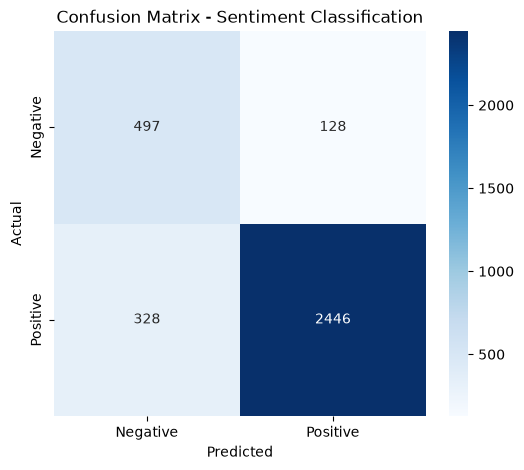

In [13]:
cm = confusion_matrix(y_test, predictions, labels=["Negative", "Positive"])

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Negative", "Positive"],
            yticklabels=["Negative", "Positive"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Sentiment Classification")
plt.show()

The confusion matrix shows the model correctly identifies 497 out of 625 
actual Negative reviews (79.5% recall), while missing 128. It also produces 
328 false positives, Positive reviews incorrectly flagged as Negative, which 
explains the 60% precision on the Negative class.

For a first baseline model, this is a reasonable trade-off: the model 
prioritizes catching negative sentiment (high recall) at the cost of some 
false alarms (lower precision). Given the project's goal of identifying 
dissatisfied customers, missing fewer negative reviews is generally more 
valuable than avoiding false alarms, though this trade-off can be tuned 
further in later iterations.

## Conclusion

A baseline sentiment classification model was built as a first step toward 
this project's Aspect-Based Sentiment Analysis goal. Star ratings were 
mapped into a binary sentiment label (Positive/Negative), and review text 
was converted into numeric features using TF-IDF.

A majority-class baseline achieved 82% accuracy but completely failed to 
identify any negative reviews (0% recall), demonstrating that accuracy 
alone is a misleading metric on this imbalanced dataset. A Logistic 
Regression model trained on the TF-IDF features improved overall accuracy 
to 87%, and more importantly, achieved 80% recall on the Negative class, 
correctly identifying most negative reviews.

This confirms that review text contains a genuine, learnable signal for 
sentiment, and establishes a working baseline pipeline (text to features 
to prediction to evaluation) that can be extended in future work, 
particularly toward per-aspect sentiment extraction, the next phase of 
this project.

**Next steps:** discuss the 2-class versus 3-class (with Neutral) decision 
with the mentor, and begin scoping the Aspect Extraction phase.